# 05 — Latent number representation: is Pythia's number line compressed?

**Purpose.** Test whether the latent number representation Pythia learns has the structure of a
*compressed mental number line* (MNL) — the signature of human numerical cognition in which
subjective distance between successive numbers shrinks as magnitude grows.

**Replicates and extends** Shah, Marupudi, Koenen, Bhardwaj & Varma (2023), *Numeric Magnitude
Comparison Effects in Large Language Models*, Findings of ACL, §4.4 / Figure 5
(<https://aclanthology.org/2023.findings-acl.383/>). That paper ran MDS on the cosine
dissimilarities of **1–9** for BERT/RoBERTa/GPT-2/T5/BART/XLNet and correlated the 1-D solution
with `log(1)…log(9)`. Here we scale the protocol to **1–100** on **Pythia-12B-deduped**, run it
**layer by layer**, and fit a **power function** to the recovered positions.

## Protocol

1. Present each integer *n* ∈ {1,…,100} to the model and read the residual-stream vector at
   *n*'s token position, at every layer (`0` = embedding output, `1…36` = output of each block).
2. Build the 100 × 100 **cosine similarity** matrix `S`, `S[i,j] = cos(v_i, v_j)`
   (diagonal 1, symmetric).
3. Convert to dissimilarity `D = 1 − S` and submit to **MDS with a 1-dimensional solution**.
4. Anchor `1` to the left (Shah et al.'s convention) and shift so `min(position) = 0`.
5. Eyeball the resulting number line: are larger numbers packed closer together?
6. Fit a **power function** `position = k · n^α + c` and record **R²**, its **p-value**, and the
   exponent **α**. In this family **α = 1 is a linear (uncompressed) number line**, **α < 1 is
   compression**, and α → 0 (with large *k*) is the logarithmic limit.

## Report → notebook map

| Report item | Section here |
|---|---|
| Latent number-line MDS (TODO_FUTURE #3, comments VS36 / VS42) | Parts 1–5 |
| Anisotropy control (not in the original protocol) | Part 6 |
| Paper-exact comparison: Table 8/9 correlations, Figure 5 pooled line | Part 8 |
| Problem-size effect in the latent arithmetic representation (second analysis) | Part 9 |
| Answer distinctiveness against c ± 1 foils | Part 10 |

**Outputs:** `../results/figures/part5nb_*.png`, `../results/tables/number_mds_layer_stats_*.csv`.

## Part 0 — Configuration and data

In [7]:
import os, json, warnings, subprocess, sys
warnings.filterwarnings("ignore")

ROOT = os.getcwd()
while ROOT != "/" and not os.path.isdir(os.path.join(ROOT, "hf", "hub")):
    ROOT = os.path.dirname(ROOT)
assert os.path.isdir(os.path.join(ROOT, "hf", "hub")), "could not locate <root>/hf/hub"
os.environ["HF_HOME"]      = os.path.join(ROOT, "hf")
os.environ["HF_HUB_CACHE"] = os.path.join(ROOT, "hf", "hub")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.manifold import MDS

MODEL_NAME = "EleutherAI/pythia-12b-deduped"
REVISION   = "step143000"
MODEL_TAG  = MODEL_NAME.split("/")[-1]
NUMBERS    = np.arange(1, 101)
SEED       = 42

# 1-D metric MDS is multi-modal: SMACOF lands in different local minima depending on the
# random initialisation, and the differences are large enough to change the fitted exponent.
# Every solution below is therefore the LOWEST-STRESS one out of MDS_N_INIT restarts pooled
# across MDS_SEEDS. Part 6 documents the spread this controls for.
MDS_N_INIT = 1000
MDS_SEEDS  = (0, 1, 42, 2024)

# Read-out templates. The primary analysis uses the bare digit string, which is what
# "present the number to the model" means literally and matches Shah et al.'s `digits`
# format; the others are robustness checks in Part 6.
TEMPLATE_PRIMARY = "{}"

REP_DIR = os.path.join(ROOT, "data", "representation")
FIG_DIR = os.path.join(ROOT, "results", "figures")
TAB_DIR = os.path.join(ROOT, "results", "tables")
for d in (REP_DIR, FIG_DIR, TAB_DIR):
    os.makedirs(d, exist_ok=True)
NPZ = os.path.join(REP_DIR, f"number_hidden_states_1_100_{MODEL_TAG}.npz")
print("root:", ROOT, "\ncache:", NPZ)

root: /storage/scratch1/9/kzhang430 
cache: /storage/scratch1/9/kzhang430/data/representation/number_hidden_states_1_100_pythia-12b-deduped.npz


In [8]:
# ── Hidden states: load the cache, or extract them (needs the GPU + ~5 min) ──────────
# scripts/extract_number_reps.py runs one forward pass per (template, number) and stores
# the residual stream at the number's token for every layer, including layer 0 = embeddings.
if not os.path.exists(NPZ):
    print("cache miss - running extraction (this loads the 12B model)")
    subprocess.run([sys.executable, os.path.join(ROOT, "scripts", "extract_number_reps.py"),
                    "--model", MODEL_NAME, "--revision", REVISION], check=True)

_d = np.load(NPZ)
VECS      = _d["vecs"]                    # (n_templates, 100, n_layers+1, hidden)
TEMPLATES = [str(t) for t in _d["templates"]]
assert (_d["numbers"] == NUMBERS).all()
N_LAYERS  = VECS.shape[2] - 1             # excluding layer 0 (embeddings)
T_PRIMARY = TEMPLATES.index(TEMPLATE_PRIMARY)

print(f"vecs {VECS.shape}  dtype={VECS.dtype}")
print(f"templates: {TEMPLATES}   (primary: {TEMPLATE_PRIMARY!r})")
print(f"layers: 0 (embeddings) .. {N_LAYERS};  hidden={VECS.shape[3]}")

vecs (3, 100, 37, 5120)  dtype=float16
templates: ['{}', ' {}', 'The number {}']   (primary: '{}')
layers: 0 (embeddings) .. 36;  hidden=5120


In [9]:
# ── Token audit: every number 1-100 must be a single token, else the read-out position
#    means different things for different n. ────────────────────────────────────────────
audit = pd.DataFrame(json.load(open(os.path.join(REP_DIR, f"number_token_audit_{MODEL_TAG}.json"))))
print(audit.groupby("template")["n_tokens_number"].value_counts().rename("count").to_string())
print("\nGPT-NeoX gives every integer 1-100 its own token, so the read-out is one vector per "
      "number with no sub-word averaging.")

template       n_tokens_number
 {}            1                  100
The number {}  1                  100
{}             1                  100

GPT-NeoX gives every integer 1-100 its own token, so the read-out is one vector per number with no sub-word averaging.


## Part 1 — Cosine similarity matrix and 1-D MDS

`cosine_similarity_matrix` returns `S` with an exact unit diagonal and exact symmetry.
MDS is run on `D = 1 − S` with `n_components=1`.

Two MDS variants are computed:

* **metric SMACOF** (`sklearn.manifold.MDS`, the default workhorse) — primary;
* **classical (Torgerson) MDS** — deterministic, no random restarts, used to confirm the
  SMACOF solution is not an artefact of initialisation.

`anchor_positions` fixes the two invariances of a 1-D MDS solution (reflection, translation)
by putting `1` to the left of `100` and shifting the minimum to 0.

In [10]:
def cosine_similarity_matrix(X):
    """Return the exact-symmetric, unit-diagonal cosine similarity matrix of rows of X."""
    X  = np.asarray(X, dtype=np.float64)
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    S  = Xn @ Xn.T
    S  = (S + S.T) / 2.0            # kill float asymmetry
    np.fill_diagonal(S, 1.0)
    return np.clip(S, -1.0, 1.0)


def mds_1d(S, n_init=MDS_N_INIT, seeds=MDS_SEEDS):
    """Metric MDS (SMACOF), 1-D, on D = 1 - S; lowest-stress solution over pooled restarts."""
    D = np.clip(1.0 - S, 0.0, None)
    np.fill_diagonal(D, 0.0)
    best = None
    for sd in seeds:
        m = MDS(n_components=1, dissimilarity="precomputed", metric=True,
                random_state=sd, n_init=n_init, max_iter=3000, eps=1e-9,
                normalized_stress=False, n_jobs=-1)
        pos = m.fit_transform(D).ravel()
        if best is None or m.stress_ < best[1]:
            best = (pos, float(m.stress_))
    return best


def kruskal_stress1(S, pos):
    """Stress-1 = sqrt(sum (d - dhat)^2 / sum d^2): unitless, comparable across layers.

    Raw SMACOF stress is not comparable between layers, because in anisotropic layers
    every dissimilarity is tiny and the raw stress shrinks with them.
    """
    D  = np.clip(1.0 - S, 0.0, None); np.fill_diagonal(D, 0.0)
    Dh = np.abs(pos[:, None] - pos[None, :])
    iu = np.triu_indices(len(pos), 1)
    denom = float(np.sum(D[iu] ** 2))
    return float(np.sqrt(np.sum((D[iu] - Dh[iu]) ** 2) / denom)) if denom > 0 else np.nan


def cmdscale_1d(S):
    """Classical (Torgerson) MDS, 1-D: leading eigenvector of the double-centred -D^2/2."""
    D = np.clip(1.0 - S, 0.0, None)
    np.fill_diagonal(D, 0.0)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    w, V = np.linalg.eigh((B + B.T) / 2)
    i = int(np.argmax(w))
    return V[:, i] * np.sqrt(max(w[i], 0.0))


def anchor_positions(pos, numbers=NUMBERS):
    """Fix the two invariances of a 1-D MDS solution.

    Reflection is resolved by orienting the line so it runs small -> large
    (Spearman rho >= 0); translation by shifting the minimum to 0. For a genuine
    number line this puts 1 at the left, which is Shah et al.'s convention -- the
    `one_leftmost` column below records whether it actually did. Note that R^2 and
    the power exponent are invariant to reflection (the scale factor k absorbs it),
    so this choice affects only the picture, never the statistics.
    """
    pos = np.asarray(pos, dtype=float).copy()
    if stats.spearmanr(np.asarray(numbers, float), pos)[0] < 0:
        pos = -pos
    return pos - pos.min()



def layer_cosine(layer, template_idx=None, center=False):
    """Cosine similarity matrix for a layer without paying for an MDS solve."""
    ti = T_PRIMARY if template_idx is None else template_idx
    X = VECS[ti, :, layer, :].astype(np.float64)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    return cosine_similarity_matrix(X)


def layer_positions(layer, template_idx=None, center=False, classical=False):
    """Full pipeline for one layer: vectors -> S -> 1-D MDS -> anchored positions."""
    ti = T_PRIMARY if template_idx is None else template_idx
    X  = VECS[ti, :, layer, :].astype(np.float64)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    S = cosine_similarity_matrix(X)
    if classical:
        pos, stress = cmdscale_1d(S), np.nan
    else:
        pos, stress = mds_1d(S)
    return anchor_positions(pos), S, stress

print("helpers defined")

helpers defined


In [11]:
# ── Sanity check on one layer's similarity matrix ────────────────────────────────────
_pos, _S, _stress = layer_positions(3)
print(f"S shape {_S.shape}   symmetric: {np.allclose(_S, _S.T)}   "
      f"unit diagonal: {np.allclose(np.diag(_S), 1.0)}")
print(f"off-diagonal cosine similarity: min {_S[np.triu_indices(100,1)].min():.4f}  "
      f"mean {_S[np.triu_indices(100,1)].mean():.4f}  max {_S[np.triu_indices(100,1)].max():.4f}")

S shape (100, 100)   symmetric: True   unit diagonal: True
off-diagonal cosine similarity: min 0.9263  mean 0.9602  max 0.9859


## Part 2 — Curve fitting

The compression claim is a claim about *shape*. A single **power** model is fit to the MDS
positions:

| model | form | free params | reading |
|---|---|---|---|
| **power** | `y = k·n^α + c` | 3 | **α < 1 compressed, α = 1 linear, α → 0 (large k) log-compressed, α > 1 expanded** |

The free offset `c` absorbs the arbitrary MDS origin; without it the fit is forced through an
anchor point that MDS never determined. `R²` is computed on the original scale, the reported `p`
is the overall F-test against an intercept-only model, and `p(α≠1)` is a Wald test of the
compression exponent itself, testing directly against the uncompressed (linear) case. Because
MDS positions are not independent observations, the F-test p-value is optimistic — a
label-permutation p-value is computed for the headline layer in Part 4 as the honest check.

In [6]:
def _r2(y, yhat):
    ss_res = float(np.sum((y - yhat) ** 2)); ss_tot = float(np.sum((y - y.mean()) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def _overall_F(y, yhat, k):
    n = len(y)
    sse = float(np.sum((y - yhat) ** 2)); sst = float(np.sum((y - y.mean()) ** 2))
    df1, df2 = k - 1, n - k
    if sse <= 0 or df1 < 1 or df2 < 1:
        return np.nan, np.nan
    F = ((sst - sse) / df1) / (sse / df2)
    return float(F), float(stats.f.sf(F, df1, df2))

def _power(x, k, a, c):
    return k * np.power(x, a) + c

def fit_power(x, y, restarts=(0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0)):
    """y = k*x^alpha + c by least squares, multi-start over alpha to avoid local minima."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    best = None
    span = (y.max() - y.min()) or 1.0
    for a0 in restarts:
        denom = (x.max() ** a0 - x.min() ** a0) or 1.0
        try:
            popt, pcov = curve_fit(_power, x, y, p0=[span / denom, a0, y.min()], maxfev=100000)
        except Exception:
            continue
        sse = float(np.sum((y - _power(x, *popt)) ** 2))
        if best is None or sse < best[0]:
            best = (sse, popt, pcov)
    if best is None:
        return dict(model="power", k=np.nan, alpha=np.nan, c=np.nan, alpha_se=np.nan,
                    r2=np.nan, F=np.nan, p=np.nan, p_alpha_vs_1=np.nan,
                    yhat=np.full_like(y, np.nan))
    _, popt, pcov = best
    yhat = _power(x, *popt)
    se = np.sqrt(np.diag(pcov)) if np.all(np.isfinite(pcov)) else np.full(3, np.nan)
    F, p = _overall_F(y, yhat, 3)
    z = (popt[1] - 1.0) / se[1] if np.isfinite(se[1]) and se[1] > 0 else np.nan
    return dict(model="power", k=float(popt[0]), alpha=float(popt[1]), c=float(popt[2]),
                alpha_se=float(se[1]), r2=_r2(y, yhat), F=F, p=p,
                p_alpha_vs_1=float(2 * stats.norm.sf(abs(z))) if np.isfinite(z) else np.nan,
                yhat=yhat)

print("fitters defined")


fitters defined


## Part 3 — Layer sweep

The whole pipeline is repeated for every layer, `0` (embeddings) through `36`.

Three diagnostics travel with each layer:

* `mean_cos` — the mean off-diagonal cosine similarity. As it approaches 1 the representations are
  *anisotropic*: every number vector points in nearly the same direction and the dissimilarity
  matrix loses its dynamic range. Structure can still be recovered from it, but the margin over
  noise is thin, so Part 6 re-runs everything with that common component removed.
* `stress1` — Kruskal stress-1, `sqrt(Σ(d − d̂)² / Σd²)`. Unlike raw SMACOF stress this is unitless
  and therefore comparable *across* layers; raw stress shrinks automatically in anisotropic layers
  simply because all the dissimilarities there are tiny.
* `alpha` — the power-fit exponent. Because `k·n^α + c` tends to the logarithmic shape as `α → 0`
  (with `k` growing to compensate), a layer reported as `alpha ≈ 0` is one whose number line is
  log-compressed, not one whose fit failed.

In [7]:
def analyse_layer(layer, template_idx=None, center=False, classical=False):
    pos, S, stress = layer_positions(layer, template_idx, center, classical)
    x = NUMBERS.astype(float)
    fp = fit_power(x, pos)
    off = S[np.triu_indices(len(NUMBERS), 1)]
    rho, rho_p = stats.spearmanr(x, pos)
    return pos, dict(
        layer=layer, mean_cos=float(off.mean()), sd_cos=float(off.std()),
        stress_raw=stress, stress1=kruskal_stress1(S, pos),
        one_leftmost=bool(np.argmin(pos) == 0),
        spearman_rho=float(rho), spearman_p=float(rho_p),
        pow_r2=fp["r2"], pow_p=fp["p"], alpha=fp["alpha"], alpha_se=fp["alpha_se"],
        p_alpha_vs_1=fp["p_alpha_vs_1"],
    )

sweep_rows, sweep_pos = [], {}
for L in range(N_LAYERS + 1):
    pos, row = analyse_layer(L)
    sweep_rows.append(row); sweep_pos[L] = pos

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(os.path.join(TAB_DIR, f"number_mds_layer_stats_{MODEL_TAG}.csv"), index=False)

pd.set_option("display.width", 220)
show = ["layer", "mean_cos", "stress1", "spearman_rho", "one_leftmost",
        "pow_r2", "alpha", "alpha_se", "pow_p"]
print(sweep[show].to_string(index=False, float_format=lambda v: f"{v: .4g}"))


 layer  mean_cos  stress1  spearman_rho  one_leftmost  pow_r2      alpha  alpha_se      pow_p
     0    0.1831   0.5677        0.2559         False  0.0892   0.001944    0.4928    0.01076
     1    0.9153   0.5195        0.5649         False  0.3287      1.995     0.727  4.021e-09
     2    0.9315   0.4732        0.8388         False  0.6653     0.8186    0.1965  8.834e-24
     3    0.9602   0.4495        0.8733         False    0.71     0.6738    0.1602  8.438e-27
     4    0.9998   0.4179        0.9093          True  0.7291     0.8233    0.1694  3.075e-28
     5    0.9999   0.4159        0.8845          True  0.6792     0.6084    0.1644  1.122e-24
     6    0.9999    0.416        0.8841          True  0.6795     0.6048    0.1639  1.073e-24
     7    0.9999   0.4176        0.8791          True  0.6777     0.5823    0.1619  1.418e-24
     8    0.9999   0.4183        0.8834          True  0.6852     0.5872    0.1597  4.521e-25
     9    0.9999   0.4171        0.8973          True   0.71

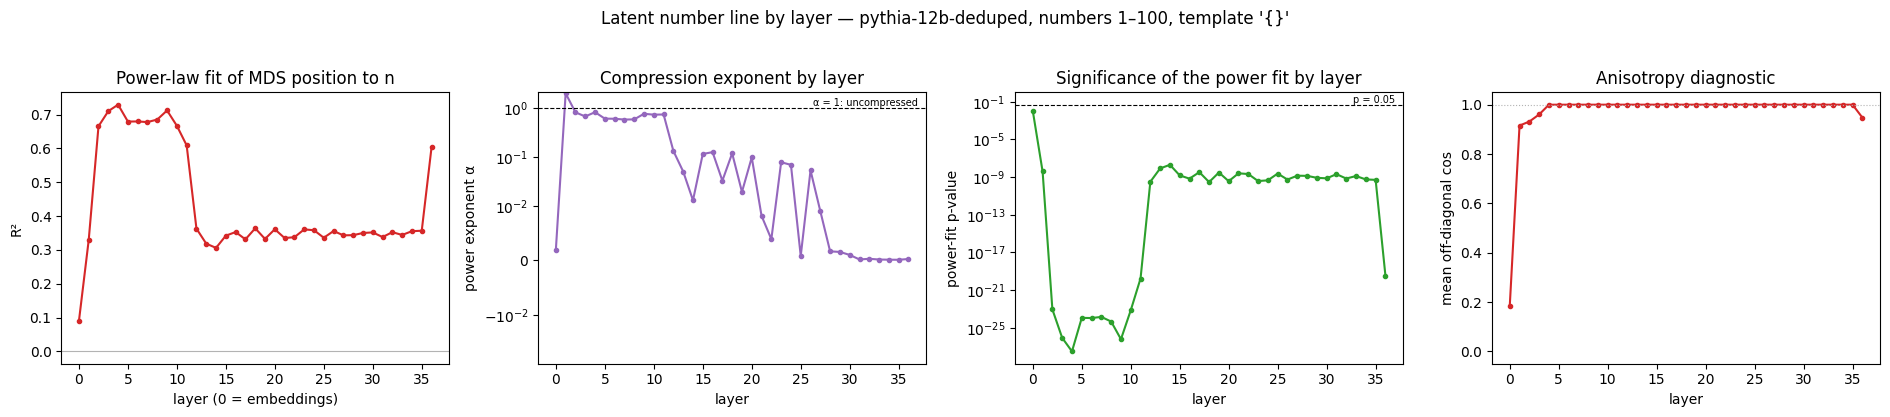

In [8]:
# ── Layer profile ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(19, 4))

ax = axes[0]
ax.plot(sweep["layer"], sweep["pow_r2"], "o-", ms=3, color="tab:red")
ax.set_xlabel("layer (0 = embeddings)"); ax.set_ylabel("R²")
ax.set_title("Power-law fit of MDS position to n"); ax.axhline(0, color="0.7", lw=.8)

ax = axes[1]
ax.plot(sweep["layer"], sweep["alpha"], "o-", ms=3, color="tab:purple")
ax.axhline(1, color="k", ls="--", lw=.8)
ax.text(0.98, 1.02, "α = 1: uncompressed", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=7)
ax.set_yscale("symlog", linthresh=1e-2)
ax.set_xlabel("layer"); ax.set_ylabel("power exponent α")
ax.set_title("Compression exponent by layer")

ax = axes[2]
ax.plot(sweep["layer"], sweep["pow_p"], "o-", ms=3, color="tab:green")
ax.axhline(0.05, color="k", ls="--", lw=.8)
ax.text(0.98, 0.05, "p = 0.05", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=7)
ax.set_yscale("log")
ax.set_xlabel("layer"); ax.set_ylabel("power-fit p-value")
ax.set_title("Significance of the power fit by layer")

ax = axes[3]
ax.plot(sweep["layer"], sweep["mean_cos"], "o-", ms=3, color="tab:red")
ax.set_xlabel("layer"); ax.set_ylabel("mean off-diagonal cos")
ax.set_title("Anisotropy diagnostic"); ax.set_ylim(-0.05, 1.05)
ax.axhline(1, color="0.7", lw=.8, ls=":")

fig.suptitle(f"Latent number line by layer — {MODEL_TAG}, numbers 1–100, template {TEMPLATE_PRIMARY!r}",
             y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_number_mds_layer_profile.png"), dpi=150,
            bbox_inches="tight")
plt.show()


## Part 4 — The headline layer: eyeball the number line, then fit it

The layer with the highest power-fit R² is taken as the best case for the compressed-number-line
hypothesis. Three views:

* **left** — the recovered line itself, numbers placed at their MDS positions (Shah et al.'s
  Figure 5 view). A compressed line crowds the large numbers toward the right end.
* **middle** — position against `n`, with the power fit drawn on.
* **right** — the 100 × 100 cosine similarity matrix the MDS was run on.

In [9]:
BEST = int(sweep.loc[sweep["pow_r2"].idxmax(), "layer"])
pos  = sweep_pos[BEST]
x    = NUMBERS.astype(float)
fp   = fit_power(x, pos)

print(f"Best layer by power R²: layer {BEST} of {N_LAYERS}")
print(f"  power  : R² = {fp['r2']:.4f}  F(2,97) = {fp['F']:.1f}  p = {fp['p']:.3g}   "
      f"α = {fp['alpha']:.3f} ± {fp['alpha_se']:.3f}  (p vs α=1: {fp['p_alpha_vs_1']:.3g})")
print(f"  Spearman ρ(n, position) = {stats.spearmanr(x, pos)[0]:.3f}")

# Permutation test: how often does a random relabelling of the same positions fit this well?
rng = np.random.default_rng(SEED)
perm_r2 = np.array([fit_power(x, rng.permutation(pos))["r2"] for _ in range(1000)])
perm_ok = perm_r2[np.isfinite(perm_r2)]
p_perm = (np.sum(perm_ok >= fp["r2"]) + 1) / (len(perm_ok) + 1)
print(f"  permutation p (1000 shuffles of n) = {p_perm:.4f}   "
      f"[null R² 95th pct = {np.percentile(perm_ok, 95):.3f}, "
      f"{len(perm_ok)}/{len(perm_r2)} fits converged]")


Best layer by power R²: layer 4 of 36
  power  : R² = 0.7291  F(2,97) = 130.6  p = 3.07e-28   α = 0.823 ± 0.169  (p vs α=1: 0.297)
  Spearman ρ(n, position) = 0.909


  permutation p (1000 shuffles of n) = 0.0010   [null R² 95th pct = 0.055, 998/1000 fits converged]


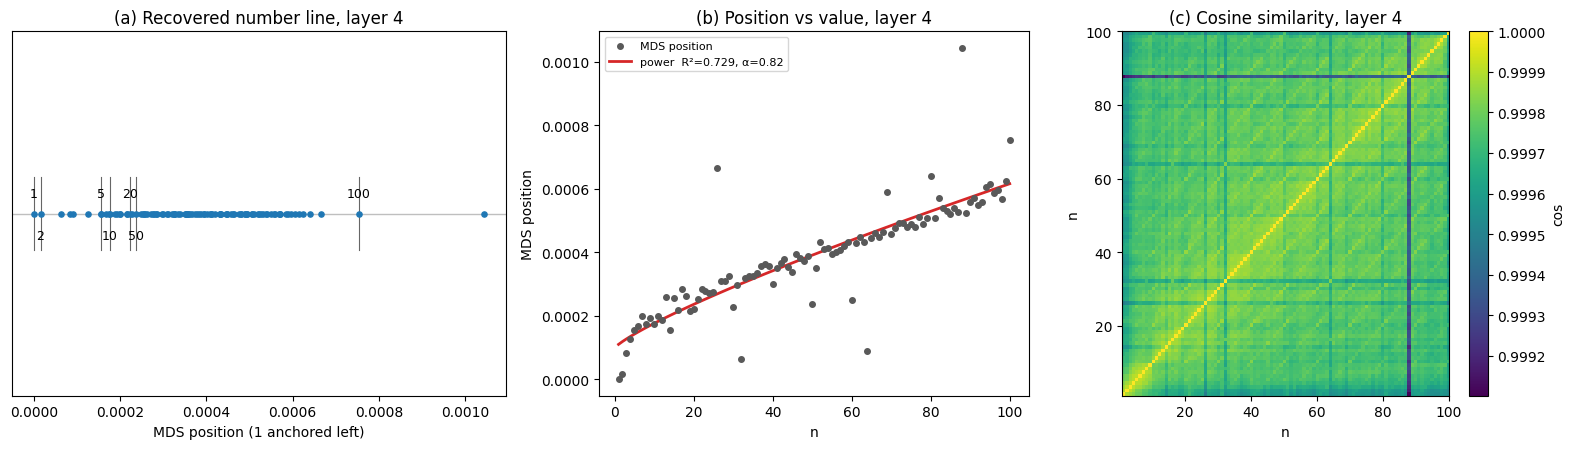

In [10]:
fig = plt.figure(figsize=(16, 4.6))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.15, 1, .95])

# (a) the recovered number line
ax = fig.add_subplot(gs[0, 0])
ax.scatter(pos, np.zeros_like(pos), s=14, color="tab:blue", zorder=3)
_labels = [1, 2, 5, 10, 20, 50, 100]
for _i, n in enumerate(_labels):
    xp = pos[n - 1]
    ax.annotate(str(n), (xp, 0), textcoords="offset points",
                xytext=(0, 12 if _i % 2 == 0 else -18), ha="center", fontsize=9)
    ax.plot([xp, xp], [-0.012, 0.012], color="0.4", lw=.8, zorder=2)
ax.axhline(0, color="0.75", lw=1, zorder=1)
ax.set_yticks([]); ax.set_ylim(-.06, .06)
ax.set_xlabel("MDS position (1 anchored left)")
ax.set_title(f"(a) Recovered number line, layer {BEST}")

# (b) position vs n with the power fit
ax = fig.add_subplot(gs[0, 1])
ax.scatter(x, pos, s=16, color="0.35", label="MDS position", zorder=3)
order = np.argsort(x)
ax.plot(x[order], fp["yhat"][order], lw=2.0, color="tab:red",
        label=f"power  R²={fp['r2']:.3f}, α={fp['alpha']:.2f}")
ax.set_xlabel("n"); ax.set_ylabel("MDS position")
ax.set_title(f"(b) Position vs value, layer {BEST}"); ax.legend(fontsize=8, loc="best")

# (c) the similarity matrix behind it
ax = fig.add_subplot(gs[0, 2])
_, S_best, _ = layer_positions(BEST)
im = ax.imshow(S_best, cmap="viridis", origin="lower",
               extent=[1, 100, 1, 100], aspect="auto")
ax.set_xlabel("n"); ax.set_ylabel("n")
ax.set_title(f"(c) Cosine similarity, layer {BEST}")
plt.colorbar(im, ax=ax, label="cos")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_number_line_best_layer.png"), dpi=150,
            bbox_inches="tight")
plt.show()

### Compression, measured directly

The power exponent is one summary of compression; a more direct one asks whether **successive
numbers get closer together**. For a compressed line the gap `|pos(n+1) − pos(n)|` shrinks with
`n`; on a log-compressed line it falls as `1/n`, i.e. slope −1 in log-log; on a linear line the
gap is flat (slope 0). The gap regression is also less sensitive than the power fit to the
handful of large-magnitude outliers that MDS can place far from the crowd.

In [11]:
pos01 = (pos - pos.min()) / (pos.max() - pos.min())   # scale-free; slope below is unaffected
gaps  = np.abs(np.diff(pos01))
mid   = (NUMBERS[:-1] + NUMBERS[1:]) / 2.0
ok    = gaps > 0
lr_gap = stats.linregress(np.log(mid[ok]), np.log(gaps[ok]))
print(f"log|gap| ~ log n : slope = {lr_gap.slope:+.3f} (SE {lr_gap.stderr:.3f}), "
      f"R² = {lr_gap.rvalue**2:.3f}, p = {lr_gap.pvalue:.3g}   [n = {ok.sum()} gaps]")
print("  slope  0 → evenly spaced (linear line);  −1 → log-compressed;  "
      f"here → {'compressed' if lr_gap.slope < 0 else 'expanded'}"
      f"{' (n.s.)' if lr_gap.pvalue > .05 else ''}")

decile = pd.DataFrame({"n": mid[ok], "gap": gaps[ok]})
decile["decade"] = ((decile["n"] // 10) * 10).astype(int)
print("\nMean gap between successive numbers, by decade:")
print(decile.groupby("decade")["gap"].agg(["mean", "count"]).round(4).to_string())

log|gap| ~ log n : slope = -0.019 (SE 0.163), R² = 0.000, p = 0.908   [n = 99 gaps]
  slope  0 → evenly spaced (linear line);  −1 → log-compressed;  here → compressed (n.s.)

Mean gap between successive numbers, by decade:
          mean  count
decade               
0       0.0281      9
10      0.0471     10
20      0.0904     10
30      0.0637     10
40      0.0347     10
50      0.0445     10
60      0.1167     10
70      0.0256     10
80      0.1297     10
90      0.0338     10


## Part 5 — Residuals against the human MNL

Shah et al. (Table 10) compare each number's position to where the log-compressed human MNL
would put it. Reproduced here on 1–100: positions and `log(n)` are each min–max scaled to
[0, 1], and the residual is `model − human`. Positive residuals are numbers the model places
*further right* (treats as larger/more distinct) than the human MNL predicts.

In [12]:
obs = (pos - pos.min()) / (pos.max() - pos.min())
hum = np.log(NUMBERS.astype(float))
hum = (hum - hum.min()) / (hum.max() - hum.min())
res = pd.DataFrame({"n": NUMBERS, "model": obs, "human_MNL": hum, "residual": obs - hum})
res["prominent"] = res["n"].isin([1, 2, 5, 10, 12, 15, 20, 24, 25, 50, 100])
res.to_csv(os.path.join(TAB_DIR, f"number_mds_residuals_{MODEL_TAG}.csv"), index=False)

print(f"mean |residual| = {res['residual'].abs().mean():.3f}   "
      f"r(model, human MNL) = {stats.pearsonr(obs, hum)[0]:.3f}")
print("\nCulturally prominent numbers:")
print(res[res["prominent"]].round(3).to_string(index=False))
print("\nLargest |residual|:")
print(res.reindex(res["residual"].abs().sort_values(ascending=False).index)
         .head(10).round(3).to_string(index=False))

mean |residual| = 0.422   r(model, human MNL) = 0.804

Culturally prominent numbers:
  n  model  human_MNL  residual  prominent
  1  0.000      0.000     0.000       True
  2  0.014      0.151    -0.136       True
  5  0.149      0.349    -0.200       True
 10  0.168      0.500    -0.332       True
 12  0.179      0.540    -0.361       True
 15  0.244      0.588    -0.344       True
 20  0.212      0.651    -0.438       True
 24  0.259      0.690    -0.431       True
 25  0.264      0.699    -0.435       True
 50  0.227      0.849    -0.622       True
100  0.722      1.000    -0.278       True

Largest |residual|:
 n  model  human_MNL  residual  prominent
64  0.086      0.903    -0.817      False
32  0.061      0.753    -0.692      False
60  0.238      0.889    -0.651      False
50  0.227      0.849    -0.622       True
30  0.218      0.739    -0.520      False
51  0.335      0.854    -0.519      False
40  0.286      0.801    -0.515      False
45  0.323      0.827    -0.503      False


## Part 6 — Robustness: anisotropy, read-out context, and MDS variant

Three things could manufacture — or destroy — the result above.

1. **Anisotropy.** In deep residual streams every token vector inherits a large shared component,
   so all cosines crowd toward 1 and the dissimilarity matrix loses its dynamic range. The
   standard correction is to mean-centre the 100 vectors before computing cosines, which removes
   that common component.
2. **Read-out context.** A bare digit string is a single-token sequence, so at every layer the
   only thing the token can attend to is itself — position 0 of a decoder-only model, which is
   exactly where attention-sink behaviour lives. Templates that give the number a left context
   (`" {}"`, `"The number {}"`) test whether the structure depends on that degenerate setting.
3. **MDS variant.** Classical (Torgerson) MDS is deterministic; agreement with SMACOF rules out
   an initialisation artefact.

In [13]:
# ── Anisotropy: raw vs mean-centred, all layers ──────────────────────────────────────
rob_rows = []
for L in range(N_LAYERS + 1):
    for cen in (False, True):
        _, r = analyse_layer(L, center=cen)
        r["prep"] = "centred" if cen else "raw"
        rob_rows.append(r)
rob = pd.DataFrame(rob_rows)

piv = rob.pivot(index="layer", columns="prep", values=["mean_cos", "spearman_rho", "pow_r2"])
print(piv.round(3).to_string())

      mean_cos        spearman_rho         pow_r2       
prep   centred    raw      centred    raw centred    raw
layer                                                   
0       -0.010  0.183        0.364  0.256   0.141  0.089
1       -0.010  0.915        0.460  0.565   0.277  0.329
2       -0.010  0.931        0.504  0.839   0.305  0.665
3       -0.009  0.960        0.792  0.873   0.659  0.710
4       -0.005  1.000        0.278  0.909   0.119  0.729
5       -0.005  1.000        0.183  0.884   0.078  0.679
6       -0.005  1.000        0.126  0.884   0.064  0.680
7       -0.005  1.000        0.122  0.879   0.062  0.678
8       -0.005  1.000        0.116  0.883   0.060  0.685
9       -0.005  1.000        0.114  0.897   0.059  0.712
10      -0.005  1.000        0.110  0.884   0.058  0.667
11      -0.005  1.000        0.114  0.881   0.059  0.609
12      -0.005  1.000        0.112  0.656   0.059  0.363
13      -0.005  1.000        0.115  0.599   0.059  0.318
14      -0.005  1.000        0.

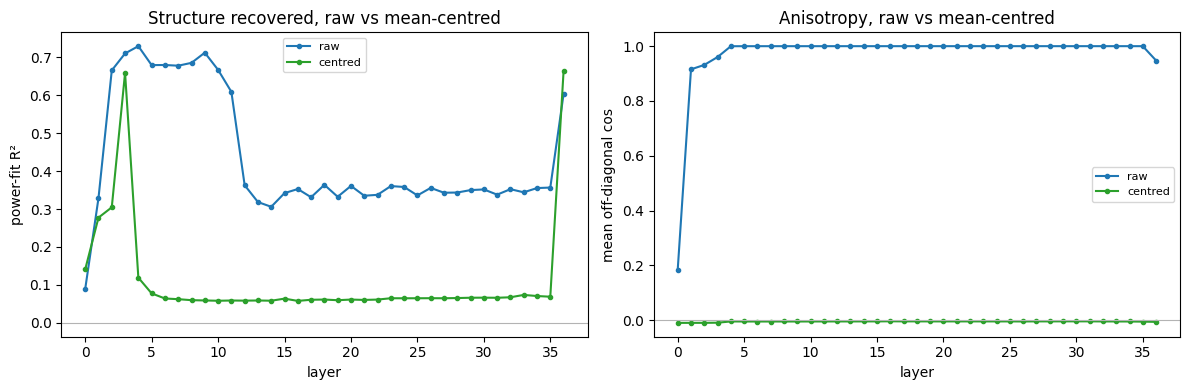

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for prep, c in [("raw", "tab:blue"), ("centred", "tab:green")]:
    s = rob[rob["prep"] == prep]
    axes[0].plot(s["layer"], s["pow_r2"], "o-", ms=3, color=c, label=prep)
    axes[1].plot(s["layer"], s["mean_cos"], "o-", ms=3, color=c, label=prep)
axes[0].set_ylabel("power-fit R²"); axes[0].set_title("Structure recovered, raw vs mean-centred")
axes[1].set_ylabel("mean off-diagonal cos"); axes[1].set_title("Anisotropy, raw vs mean-centred")
for ax in axes:
    ax.set_xlabel("layer"); ax.legend(fontsize=8); ax.axhline(0, color="0.7", lw=.8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_number_mds_anisotropy.png"), dpi=150, bbox_inches="tight")
plt.show()

Best layer per read-out template (by power R²):
       template  layer  mean_cos  spearman_rho  pow_r2   alpha       pow_p
'The number {}'      4    0.9372        0.9972  0.9929   1.034  4.745e-105
          ' {}'      2    0.9294        0.9262  0.8457  0.8333   4.352e-40
           '{}'      4    0.9998        0.9093  0.7291  0.8233   3.075e-28


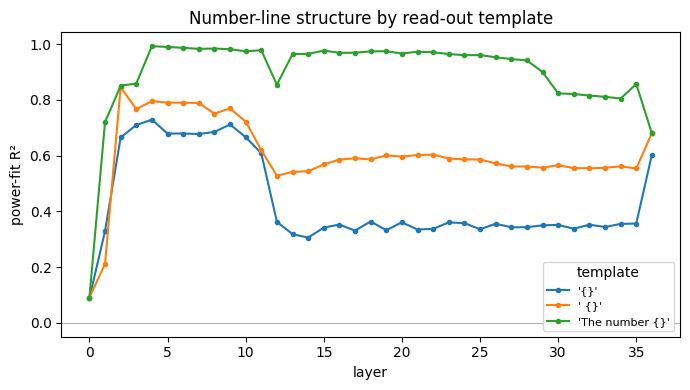

In [15]:
# ── Read-out context: one row per template x layer, best layer per template ──────────
tpl_rows = []
for ti, t in enumerate(TEMPLATES):
    for L in range(N_LAYERS + 1):
        _, r = analyse_layer(L, template_idx=ti)
        r["template"] = t
        tpl_rows.append(r)
tpl = pd.DataFrame(tpl_rows)

best_per_tpl = (tpl.loc[tpl.groupby("template")["pow_r2"].idxmax()]
                   [["template", "layer", "mean_cos", "spearman_rho",
                     "pow_r2", "alpha", "pow_p"]]
                   .assign(template=lambda d: d["template"].map(repr))   # keep ' {}' visible
                   .sort_values("pow_r2", ascending=False))
print("Best layer per read-out template (by power R²):")
print(best_per_tpl.to_string(index=False, float_format=lambda v: f"{v: .4g}"))

fig, ax = plt.subplots(figsize=(7, 4))
for t in TEMPLATES:
    s = tpl[tpl["template"] == t]
    ax.plot(s["layer"], s["pow_r2"], "o-", ms=3, label=repr(t))
ax.set_xlabel("layer"); ax.set_ylabel("power-fit R²"); ax.axhline(0, color="0.7", lw=.8)
ax.set_title("Number-line structure by read-out template"); ax.legend(fontsize=8, title="template")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_number_mds_templates.png"), dpi=150, bbox_inches="tight")
plt.show()

### The cleanest read-out

Giving the number a left context (`"The number n"`) removes the degenerate single-token setting
and recovers a far cleaner line than the bare digit does. Because that is the strongest form of
the number-line result in this notebook, it gets the same plot treatment as the primary analysis.

template 'The number {}', layer 4:
  power  : R² = 0.9929  p = 4.75e-105   α = 1.034 ± 0.027  (p vs α=1: 0.199)
  Spearman ρ = 0.9972   mean off-diagonal cos = 0.9372
  gap slope (log|gap| ~ log n) = -0.163 (SE 0.097), p = 0.0958


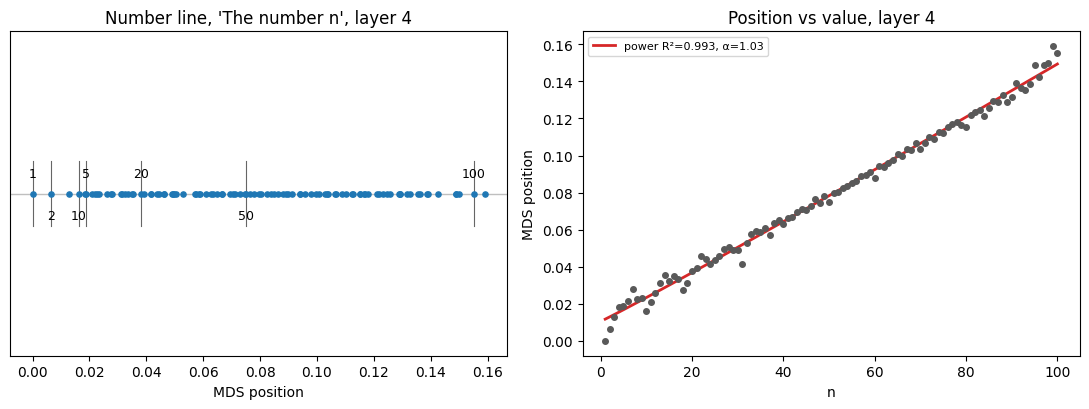

In [16]:
TI_CTX  = TEMPLATES.index("The number {}")
ctx     = tpl[tpl["template"] == "The number {}"]
L_CTX   = int(ctx.loc[ctx["pow_r2"].idxmax(), "layer"])
pos_ctx = layer_positions(L_CTX, template_idx=TI_CTX)[0]
fp_c    = fit_power(x, pos_ctx)

print(f"template 'The number {{}}', layer {L_CTX}:")
print(f"  power  : R² = {fp_c['r2']:.4f}  p = {fp_c['p']:.3g}   "
      f"α = {fp_c['alpha']:.3f} ± {fp_c['alpha_se']:.3f}  (p vs α=1: {fp_c['p_alpha_vs_1']:.3g})")
print(f"  Spearman ρ = {stats.spearmanr(x, pos_ctx)[0]:.4f}   "
      f"mean off-diagonal cos = {ctx.loc[ctx.layer == L_CTX, 'mean_cos'].iloc[0]:.4f}")

g_ctx = np.abs(np.diff((pos_ctx - pos_ctx.min()) / (pos_ctx.max() - pos_ctx.min())))
m_ctx = (NUMBERS[:-1] + NUMBERS[1:]) / 2.0
ok_c  = g_ctx > 0
lr_c  = stats.linregress(np.log(m_ctx[ok_c]), np.log(g_ctx[ok_c]))
print(f"  gap slope (log|gap| ~ log n) = {lr_c.slope:+.3f} (SE {lr_c.stderr:.3f}), "
      f"p = {lr_c.pvalue:.3g}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.scatter(pos_ctx, np.zeros_like(pos_ctx), s=14, color="tab:blue", zorder=3)
for _i, n in enumerate([1, 2, 5, 10, 20, 50, 100]):
    xp = pos_ctx[n - 1]
    ax.annotate(str(n), (xp, 0), textcoords="offset points",
                xytext=(0, 12 if _i % 2 == 0 else -18), ha="center", fontsize=9)
    ax.plot([xp, xp], [-0.012, 0.012], color="0.4", lw=.8, zorder=2)
ax.axhline(0, color="0.75", lw=1, zorder=1)
ax.set_yticks([]); ax.set_ylim(-.06, .06)
ax.set_xlabel("MDS position"); ax.set_title(f"Number line, 'The number n', layer {L_CTX}")

ax = axes[1]
ax.scatter(x, pos_ctx, s=16, color="0.35", zorder=3)
o = np.argsort(x)
ax.plot(x[o], fp_c["yhat"][o], lw=2.0, color="tab:red",
        label=f"power R²={fp_c['r2']:.3f}, α={fp_c['alpha']:.2f}")
ax.set_xlabel("n"); ax.set_ylabel("MDS position"); ax.legend(fontsize=8)
ax.set_title(f"Position vs value, layer {L_CTX}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_number_line_context_template.png"), dpi=150,
            bbox_inches="tight")
plt.show()


In [17]:
# ── MDS solution quality: local minima, and SMACOF vs classical ─────────────────────
_, S_b, _ = layer_positions(BEST)

# (a) spread across single-seed SMACOF runs, i.e. what pooling the restarts buys us
rows = []
for sd in MDS_SEEDS:
    p = anchor_positions(mds_1d(S_b, n_init=MDS_N_INIT, seeds=(sd,))[0])
    f = fit_power(x, p)
    rows.append(dict(solution=f"SMACOF seed={sd}", stress1=kruskal_stress1(S_b, p), r2=f["r2"],
                     alpha=f["alpha"], rho=stats.spearmanr(x, p)[0]))
p_cl = anchor_positions(cmdscale_1d(S_b)); f_cl = fit_power(x, p_cl)
rows.append(dict(solution="classical (Torgerson)", stress1=kruskal_stress1(S_b, p_cl), r2=f_cl["r2"],
                 alpha=f_cl["alpha"], rho=stats.spearmanr(x, p_cl)[0]))
rows.append(dict(solution="POOLED (reported above)", stress1=kruskal_stress1(S_b, pos), r2=fp["r2"],
                 alpha=fp["alpha"], rho=stats.spearmanr(x, pos)[0]))

print(f"Layer {BEST}: alternative 1-D solutions of the same dissimilarity matrix\n")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v: .5f}"))
print("\nLower stress = better MDS solution. Classical MDS often yields a higher R² here, but at")
print("higher stress: it is a worse fit to the dissimilarities, so its cleaner-looking number")
print("line is not evidence for compression. The pooled lowest-stress solution is what Parts 3-5")
print("report, and its across-seed spread is the honest uncertainty on alpha.")

Layer 4: alternative 1-D solutions of the same dissimilarity matrix

               solution  stress1       r2    alpha      rho
          SMACOF seed=0  0.41792  0.72914  0.82328  0.90927
          SMACOF seed=1  0.42741  0.69710  0.69142  0.88125
         SMACOF seed=42  0.43192  0.46627  0.94736  0.77599
       SMACOF seed=2024  0.42413  0.74502  0.91584  0.91129
  classical (Torgerson)  0.63450  0.66149  0.00021  0.82715
POOLED (reported above)  0.41792  0.72914  0.82328  0.90927

Lower stress = better MDS solution. Classical MDS often yields a higher R² here, but at
higher stress: it is a worse fit to the dissimilarities, so its cleaner-looking number
line is not evidence for compression. The pooled lowest-stress solution is what Parts 3-5
report, and its across-seed spread is the honest uncertainty on alpha.


## Part 7 — Summary

Printed below in the form the paper needs.

In [18]:
def _fmt(v, nd=3):
    return "n/a" if v is None or (isinstance(v, float) and not np.isfinite(v)) else f"{v:.{nd}f}"

summary = {
    "model": MODEL_NAME, "revision": REVISION, "numbers": "1-100",
    "template": TEMPLATE_PRIMARY, "n_layers": N_LAYERS,
    "best_layer": BEST,
    "power_R2": fp["r2"], "power_p": fp["p"], "power_alpha": fp["alpha"],
    "power_alpha_se": fp["alpha_se"], "p_alpha_vs_1": fp["p_alpha_vs_1"],
    "permutation_p": p_perm,
    "spearman_rho": float(stats.spearmanr(x, pos)[0]),
    "gap_loglog_slope": float(lr_gap.slope), "gap_loglog_p": float(lr_gap.pvalue),
    "mean_offdiag_cos_at_best": float(sweep.loc[sweep.layer == BEST, "mean_cos"].iloc[0]),
    "stress1_at_best": float(sweep.loc[sweep.layer == BEST, "stress1"].iloc[0]),
    "layers_with_mean_cos_above_0.99": int((sweep["mean_cos"] > 0.99).sum()),
    "ctx_template": "The number {}", "ctx_layer": L_CTX,
    "ctx_power_R2": fp_c["r2"], "ctx_power_alpha": fp_c["alpha"],
    "ctx_power_alpha_se": fp_c["alpha_se"],
    "ctx_spearman_rho": float(stats.spearmanr(x, pos_ctx)[0]),
    "ctx_gap_loglog_slope": float(lr_c.slope), "ctx_gap_loglog_p": float(lr_c.pvalue),
}
with open(os.path.join(TAB_DIR, f"number_mds_summary_{MODEL_TAG}.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print()
print(f"Sentence-ready (primary, bare digit): at layer {BEST} of {MODEL_TAG}, a power function "
      f"fit to the 1-D MDS positions of 1-100 gave R² = {_fmt(fp['r2'])}, p = {fp['p']:.3g}, "
      f"with exponent α = {_fmt(fp['alpha'])} (SE {_fmt(fp['alpha_se'])}).")
print()
print(f"Sentence-ready (cleanest read-out, 'The number n'): at layer {L_CTX}, R² = "
      f"{_fmt(fp_c['r2'])}, p = {fp_c['p']:.3g}, α = {_fmt(fp_c['alpha'])} "
      f"(SE {_fmt(fp_c['alpha_se'])}).")


{
  "model": "EleutherAI/pythia-12b-deduped",
  "revision": "step143000",
  "numbers": "1-100",
  "template": "{}",
  "n_layers": 36,
  "best_layer": 4,
  "power_R2": 0.7291443110032456,
  "power_p": 3.074617889270831e-28,
  "power_alpha": 0.8232814290459226,
  "power_alpha_se": 0.1693858218246598,
  "p_alpha_vs_1": 0.2968139002526705,
  "permutation_p": 0.001001001001001001,
  "spearman_rho": 0.9092709270927092,
  "gap_loglog_slope": -0.01890932193044084,
  "gap_loglog_p": 0.9076636827652611,
  "mean_offdiag_cos_at_best": 0.9997520166775158,
  "stress1_at_best": 0.4179224245480035,
  "layers_with_mean_cos_above_0.99": 32,
  "ctx_template": "The number {}",
  "ctx_layer": 4,
  "ctx_power_R2": 0.9929368986759827,
  "ctx_power_alpha": 1.0344444653548868,
  "ctx_power_alpha_se": 0.026814926931753556,
  "ctx_spearman_rho": 0.9972397239723971,
  "ctx_gap_loglog_slope": -0.16349606730062455,
  "ctx_gap_loglog_p": 0.09578641225165892
}

Sentence-ready (primary, bare digit): at layer 4 of pyth

## Part 8 — Layer-pooled number line (Figure 5 equivalent)

Everything above fits Pythia's number line layer by layer (1–100, free power exponent). This
section instead reproduces Figure 5's headline visualization: cosine dissimilarity matrices are
averaged *across layers* before a single MDS solution is computed, so there is one pooled number
line per model rather than 37. We pool layers 1–36 only — layer 0 (the embedding output) carries
essentially no number-line structure on its own (Part 3) and would only dilute the average. We do
not pool across templates: our three templates are read-out *contexts* for the same digit tokens,
not the distinct word/digit *formats* the paper pools over, so pooling them would not be the
analogous operation.

In [19]:
S_pooled = np.mean([layer_cosine(L) for L in range(1, N_LAYERS + 1)], axis=0)
pos_pooled, stress_pooled = mds_1d(S_pooled)
pos_pooled = anchor_positions(pos_pooled)
fp_pooled  = fit_power(x, pos_pooled)
N9 = np.arange(1, 10)

print(f"Pooled number line ({MODEL_TAG}, layers 1-{N_LAYERS}, digits, numbers 1-100):")
print(f"  power  : R² = {fp_pooled['r2']:.4f}  p = {fp_pooled['p']:.3g}   "
      f"α = {fp_pooled['alpha']:.3f} ± {fp_pooled['alpha_se']:.3f}")


Pooled number line (pythia-12b-deduped, layers 1-36, digits, numbers 1-100):
  power  : R² = 0.8418  p = 1.46e-39   α = 0.905 ± 0.127


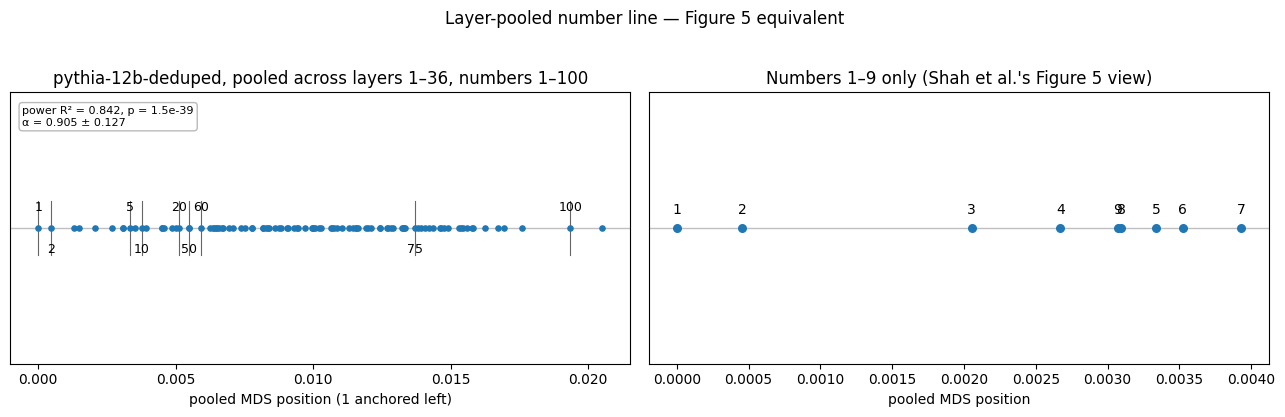

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(pos_pooled, np.zeros_like(pos_pooled), s=14, color="tab:blue", zorder=3)
for _i, n in enumerate([1, 2, 5, 10, 20, 50, 60, 75, 100]):
    xp = pos_pooled[n - 1]
    ax.annotate(str(n), (xp, 0), textcoords="offset points",
                xytext=(0, 12 if _i % 2 == 0 else -18), ha="center", fontsize=9)
    ax.plot([xp, xp], [-0.012, 0.012], color="0.4", lw=.8, zorder=2)
ax.axhline(0, color="0.75", lw=1, zorder=1)
ax.set_yticks([]); ax.set_ylim(-.06, .06)
ax.set_xlabel("pooled MDS position (1 anchored left)")
ax.set_title(f"{MODEL_TAG}, pooled across layers 1–{N_LAYERS}, numbers 1–100")
ax.text(0.02, 0.95, f"power R² = {fp_pooled['r2']:.3f}, p = {fp_pooled['p']:.2g}\n"
        f"α = {fp_pooled['alpha']:.3f} ± {fp_pooled['alpha_se']:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=8,
        bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))

ax = axes[1]
pos9_from_pooled = pos_pooled[:9]
pos9_01 = pos9_from_pooled - pos9_from_pooled.min()
ax.scatter(pos9_01, np.zeros_like(pos9_01), s=30, color="tab:blue", zorder=3)
for n in N9:
    xp = pos9_01[n - 1]
    ax.annotate(str(n), (xp, 0), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)
ax.axhline(0, color="0.75", lw=1, zorder=1)
ax.set_yticks([]); ax.set_xlabel("pooled MDS position")
ax.set_title("Numbers 1–9 only (Shah et al.'s Figure 5 view)")

fig.suptitle("Layer-pooled number line — Figure 5 equivalent", y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_number_line_pooled_figure5.png"), dpi=150, bbox_inches="tight")
plt.show()

## Part 9 — The problem-size effect in the latent arithmetic representation

Parts 1–8 asked whether Pythia's representation of a *number* is compressed. This part asks the
companion question about *arithmetic facts*: does the representation of `a op b` point at the
answer less strongly as the problem gets bigger?

On the classic table-lookup account of arithmetic memory, facts sit in a two-dimensional table
indexed by the two operands — row `a`, column `b`, answer `c` at the intersection — and retrieval
is not uniform across it. Large problems are answered more slowly and less accurately than small
ones: the **problem-size effect**.

Method, repeated for every layer (0–36) and every operation:

1. Present `a op b =`, read the residual stream at the last token.
2. Present `c` on its own, read it out the same way.
3. Take the cosine similarity of the two.
4. Plot it against problem size `c`.

A **decreasing** function is the signature.

### The grid

Both operands are single digits 1–9 throughout.

| op | problems | answers `c` |
|---|---|---|
| `+` | all 81 pairs | 2 … 18 |
| `−` | all 81 pairs, negatives and zero kept | −8 … 8 |
| `*` | all 81 pairs | 1 … 81 |
| `/` | the 23 pairs where `b` divides `a` exactly | 1 … 9 |

Read-out details worth knowing when reading the plots:

* The prompt is `"a op b ="`, so the vector is taken at the `=`, the position where the model is
  about to emit the answer. `"a op b = c"` is deliberately not used — its last token *is* `c`, so
  the cosine would measure token identity rather than retrieval.
* The answer is presented as `" c"` with a leading space, the form it takes as a next token.
* Negative answers are two tokens (`" -"`, `"5"`), so they are read at the digit. Their layer-0
  vector is identical to the corresponding positive number's, and the sign only accumulates
  through the layers.
* **Layer 0 is plotted but never taken as the headline.** At the embedding layer the read-out
  token is `=` for every problem, so all expression vectors are identical there and the cosine is
  a function of `c` alone — a perfect-looking "effect" containing no arithmetic at all.
* For `−` the x-axis runs −8…8, so "size" means the signed answer rather than its magnitude.

In [14]:
# ── Arithmetic hidden states, plus answer vectors covering 0 and the negatives ───────────
ARITH_NPZ = os.path.join(REP_DIR, f"arith_hidden_states_{MODEL_TAG}.npz")
EXTRA_NPZ = os.path.join(REP_DIR, f"number_hidden_states_extra_{MODEL_TAG}.npz")
if not os.path.exists(ARITH_NPZ):
    print("cache miss - extracting arithmetic vectors (loads the 12B model)")
    subprocess.run([sys.executable, os.path.join(ROOT, "scripts", "extract_arith_reps.py"),
                    "--model", MODEL_NAME, "--revision", REVISION], check=True)
if not os.path.exists(EXTRA_NPZ):
    print("cache miss - extracting vectors for -9..0 (loads the 12B model)")
    subprocess.run([sys.executable, os.path.join(ROOT, "scripts", "extract_number_extras.py"),
                    "--model", MODEL_NAME, "--revision", REVISION,
                    "--numbers=" + ",".join(str(n) for n in range(-9, 1))], check=True)

_a = np.load(ARITH_NPZ)
AVECS       = _a["vecs"]                      # (n_templates, n_problems, n_layers+1, hidden)
A_TEMPLATES = [str(t) for t in _a["templates"]]
PROB = pd.DataFrame({"op": [str(o) for o in _a["ops"]],
                     "a": _a["a"], "b": _a["b"], "c": _a["c"]})
OPS    = ["+", "-", "*", "/"]
T_EQ   = A_TEMPLATES.index("{a} {op} {b} =")  # primary read-out: the "=" position
T_EXPR = A_TEMPLATES.index("{a} {op} {b}")
ANS_TI = TEMPLATES.index(" {}")               # the answer as the model would emit it: " 12"

# ANSVEC holds one vector per integer from NUM_MIN up to 100; nrow() maps a number to its row.
# The 1-100 block is the Part 0 cache; the negatives and 0 come from the extras cache.
_e   = np.load(EXTRA_NPZ)
_ord = np.argsort(_e["numbers"])
NUM_MIN = int(_e["numbers"][_ord][0])
assert [str(t) for t in _e["templates"]] == TEMPLATES, "extras use different templates"
assert list(_e["numbers"][_ord]) == list(range(NUM_MIN, 1)), "extras must run NUM_MIN..0"
ANSVEC = np.concatenate([_e["vecs"][:, _ord], VECS], axis=1)

def nrow(n):
    """Row of ANSVEC holding the vector for the integer n."""
    return np.asarray(n) - NUM_MIN

assert AVECS.shape[2] - 1 == N_LAYERS and AVECS.shape[3] == VECS.shape[3]
assert PROB["c"].between(NUM_MIN + 1, 99).all(), "an answer sits outside ANSVEC (with foil room)"

print(f"arith vecs {AVECS.shape}    answer vecs {ANSVEC.shape}  (integers {NUM_MIN}..100)")
print(f"prompt {A_TEMPLATES[T_EQ]!r}, answers read out as {TEMPLATES[ANS_TI]!r}\n")
print(PROB.groupby("op").agg(n=("c", "size"), c_min=("c", "min"), c_max=("c", "max"),
                             distinct_c=("c", "nunique")).reindex(OPS).to_string())

_au = pd.DataFrame(json.load(open(os.path.join(REP_DIR, f"arith_token_audit_{MODEL_TAG}.json"))))
_au["last"] = _au["last_token"].str.replace("Ġ", " ", regex=False)
_au["want"] = np.where(_au["template"].str.endswith("="), " =", " " + _au["b"].astype(str))
print("\nread-out position: " + ",  ".join(
    f"{t!r} {(d['last'] == d['want']).sum()}/{len(d)}" for t, d in _au.groupby("template")))

arith vecs (2, 266, 37, 5120)    answer vecs (3, 110, 37, 5120)  (integers -9..100)
prompt '{a} {op} {b} =', answers read out as ' {}'

     n  c_min  c_max  distinct_c
op                              
+   81      2     18          17
-   81     -8      8          17
*   81      1     81          36
/   23      1      9           9

read-out position: '{a} {op} {b}' 266/266,  '{a} {op} {b} =' 266/266


In [15]:
OP_COLORS = dict(zip(OPS, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))


def _unit_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / np.linalg.norm(X, axis=1, keepdims=True)


def arith_table(layer, template_idx=None, ans_template_idx=None):
    """cos(expression vector, answer vector) for every problem, at one layer."""
    ti = T_EQ if template_idx is None else template_idx
    ai = ANS_TI if ans_template_idx is None else ans_template_idx
    E = _unit_rows(AVECS[ti, :, layer, :].astype(np.float64))
    A = _unit_rows(ANSVEC[ai, :, layer, :].astype(np.float64))
    out = PROB.copy()
    out["sim"]   = np.einsum("ij,ij->i", E, A[nrow(out["c"].to_numpy())])
    out["layer"] = layer
    return out


def trend_stats(x, y):
    """Is y a decreasing function of x? Shape-free rank test plus an OLS line."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    rho, rho_p = stats.spearmanr(x, y)
    lr = stats.linregress(x, y)
    return dict(rho=float(rho), rho_p=float(rho_p), slope=float(lr.slope),
                r2=float(lr.rvalue ** 2), p=float(lr.pvalue))

print("arithmetic helpers defined")

arithmetic helpers defined


In [16]:
# ── Layer x operation sweep ──────────────────────────────────────────────────────────────
arith_rows, arith_tabs = [], {}
for L in range(N_LAYERS + 1):
    t = arith_table(L)
    arith_tabs[L] = t
    for op in OPS:
        s  = t[t["op"] == op]
        st = trend_stats(s["c"], s["sim"])
        arith_rows.append(dict(layer=L, op=op, mean_sim=float(s["sim"].mean()),
                               rho=st["rho"], slope=st["slope"], r2=st["r2"], p=st["p"]))
arith = pd.DataFrame(arith_rows)
arith.to_csv(os.path.join(TAB_DIR, f"arith_problem_size_layer_stats_{MODEL_TAG}.csv"), index=False)

print("Spearman rho(problem size c, cosine to the correct answer), by layer and operation.")
print("Negative = the predicted problem-size effect.\n")
print(arith.pivot(index="layer", columns="op", values="rho")[OPS]
      .to_string(float_format=lambda v: f"{v: .3f}"))

print("\nStrongest layer per operation (most negative rho, layer 0 excluded):")
_a1 = arith[arith["layer"] > 0]
print(_a1.loc[_a1.groupby("op")["rho"].idxmin()].set_index("op").reindex(OPS)[
    ["layer", "rho", "r2", "p", "slope", "mean_sim"]
].to_string(float_format=lambda v: f"{v: .4g}"))

Spearman rho(problem size c, cosine to the correct answer), by layer and operation.
Negative = the predicted problem-size effect.

op         +      -      *      /
layer                            
0     -0.916 -0.364 -0.931 -0.999
1     -0.429 -0.745 -0.833 -0.159
2     -0.679 -0.768 -0.825  0.077
3     -0.813 -0.847 -0.858  0.204
4      0.173 -0.852 -0.151  0.180
5     -0.056 -0.813 -0.271 -0.266
6     -0.072 -0.826 -0.001 -0.216
7     -0.277 -0.661 -0.173 -0.245
8     -0.208  0.644 -0.061 -0.025
9     -0.465  0.641 -0.105  0.128
10    -0.492 -0.430 -0.171  0.224
11    -0.465 -0.806 -0.125  0.357
12    -0.312 -0.821 -0.069  0.282
13    -0.578 -0.778 -0.202  0.438
14    -0.701 -0.768 -0.324  0.644
15    -0.733 -0.752 -0.420  0.525
16    -0.791 -0.755 -0.407  0.533
17    -0.797 -0.750 -0.484  0.480
18    -0.818 -0.744 -0.451  0.410
19    -0.849 -0.749 -0.430  0.392
20    -0.847 -0.743 -0.444  0.387
21    -0.841 -0.744 -0.458  0.398
22    -0.859 -0.729 -0.453  0.442
23    -0.843 -0.706

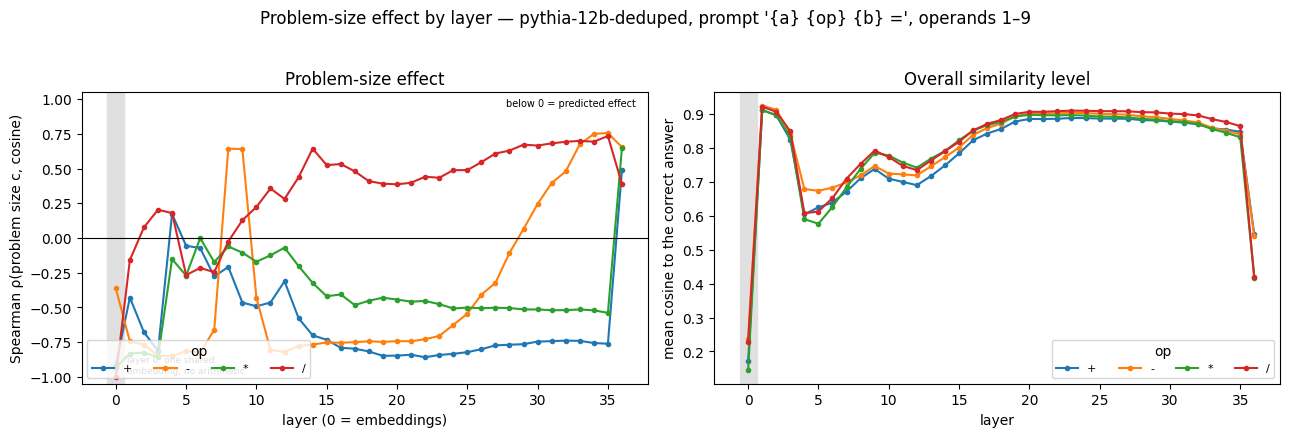

In [17]:
# ── Layer profile ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for op in OPS:
    s = arith[arith["op"] == op]
    ax.plot(s["layer"], s["rho"], "o-", ms=3, color=OP_COLORS[op], label=op)
ax.axhline(0, color="k", lw=.8)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("layer (0 = embeddings)"); ax.set_ylabel("Spearman ρ(problem size c, cosine)")
ax.set_title("Problem-size effect")
ax.text(0.98, 0.98, "below 0 = predicted effect", transform=ax.transAxes,
        ha="right", va="top", fontsize=7)
ax.legend(title="op", fontsize=8, ncol=4, loc="lower left")

ax = axes[1]
for op in OPS:
    s = arith[arith["op"] == op]
    ax.plot(s["layer"], s["mean_sim"], "o-", ms=3, color=OP_COLORS[op], label=op)
ax.set_xlabel("layer"); ax.set_ylabel("mean cosine to the correct answer")
ax.set_title("Overall similarity level")
ax.legend(title="op", fontsize=8, ncol=4)

for _ax in axes:                      # layer 0 is the bare embedding of "=", shared by all
    _ax.axvspan(-0.6, 0.6, color="0.88", zorder=0)
axes[0].text(0.6, 0.03, " layer 0: one shared\n embedding, no arithmetic", fontsize=6.5,
             transform=axes[0].get_xaxis_transform(), ha="left", va="bottom", color="0.35")

fig.suptitle(f"Problem-size effect by layer — {MODEL_TAG}, prompt {A_TEMPLATES[T_EQ]!r}, "
             f"operands 1–9", y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_arith_problem_size_layer_profile.png"), dpi=150,
            bbox_inches="tight")
plt.show()

Headline layer 3 of 36



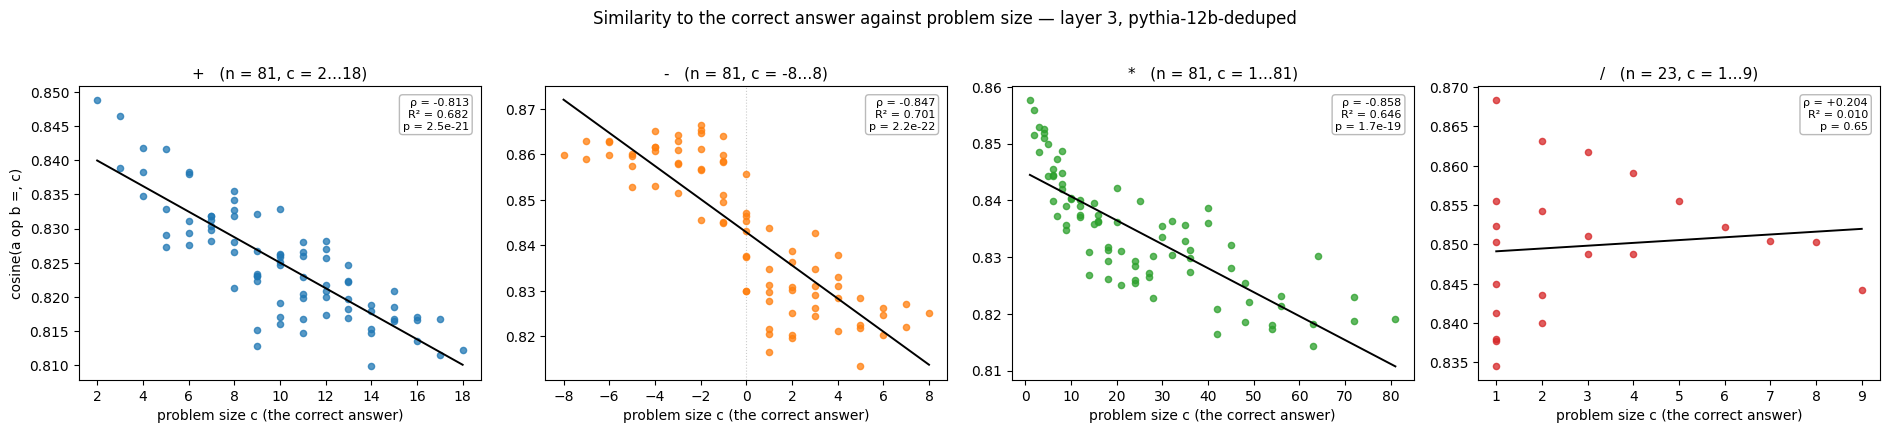

In [18]:
# Headline layer: strongest average decrease across operations. Layer 0 excluded -- every
# expression shares one embedding there, so its cosine is a function of c alone.
ABEST = int(arith[arith["layer"] > 0].groupby("layer")["rho"].mean().idxmin())
atab  = arith_tabs[ABEST]
print(f"Headline layer {ABEST} of {N_LAYERS}\n")

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for j, op in enumerate(OPS):
    s  = atab[atab["op"] == op]
    ax = axes[j]
    ax.scatter(s["c"], s["sim"], s=20, color=OP_COLORS[op], alpha=.75, zorder=3)
    lr = stats.linregress(s["c"].astype(float), s["sim"].astype(float))
    xx = np.linspace(s["c"].min(), s["c"].max(), 50)
    ax.plot(xx, lr.intercept + lr.slope * xx, color="k", lw=1.4, zorder=4)
    rho = stats.spearmanr(s["c"], s["sim"])[0]
    ax.text(.97, .96, f"ρ = {rho:+.3f}\nR² = {lr.rvalue ** 2:.3f}\np = {lr.pvalue:.2g}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=.9))
    if op == "-":
        ax.axvline(0, color="0.8", lw=.8, ls=":", zorder=1)
    ax.set_title(f"{op}   (n = {len(s)}, c = {s.c.min()}…{s.c.max()})", fontsize=11)
    ax.set_xlabel("problem size c (the correct answer)")
    if j == 0:
        ax.set_ylabel("cosine(a op b =, c)")

fig.suptitle(f"Similarity to the correct answer against problem size — layer {ABEST}, {MODEL_TAG}",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_arith_problem_size_scatter.png"), dpi=150,
            bbox_inches="tight")
plt.show()

In [19]:
arith_summary = {
    "model": MODEL_NAME, "revision": REVISION,
    "expr_template": A_TEMPLATES[T_EQ], "answer_template": TEMPLATES[ANS_TI],
    "headline_layer": ABEST, "n_layers": N_LAYERS, "by_operation": {},
}
for op in OPS:
    r = arith[(arith["layer"] == ABEST) & (arith["op"] == op)].iloc[0]
    b = _a1.loc[_a1[_a1["op"] == op]["rho"].idxmin()]
    arith_summary["by_operation"][op] = {
        "n": int((PROB["op"] == op).sum()),
        "c_range": [int(PROB.loc[PROB["op"] == op, "c"].min()),
                    int(PROB.loc[PROB["op"] == op, "c"].max())],
        "rho": float(r["rho"]), "p": float(r["p"]), "R2": float(r["r2"]),
        "slope": float(r["slope"]), "mean_cosine": float(r["mean_sim"]),
        "best_layer_by_rho": int(b["layer"]), "best_rho": float(b["rho"]),
    }
with open(os.path.join(TAB_DIR, f"arith_problem_size_summary_{MODEL_TAG}.json"), "w") as f:
    json.dump(arith_summary, f, indent=2)
print(json.dumps(arith_summary, indent=2))

_r = {op: arith_summary["by_operation"][op]["rho"] for op in OPS}
print()
print(f"Sentence-ready: at layer {ABEST} of {MODEL_TAG}, the cosine between the residual stream "
      f"at the '=' of 'a op b =' and the vector for the correct answer c fell with problem size, "
      + ", ".join(f"ρ({op}) = {v:+.3f}" for op, v in _r.items()) + " (Spearman).")

{
  "model": "EleutherAI/pythia-12b-deduped",
  "revision": "step143000",
  "expr_template": "{a} {op} {b} =",
  "answer_template": " {}",
  "headline_layer": 3,
  "n_layers": 36,
  "by_operation": {
    "+": {
      "n": 81,
      "c_range": [
        2,
        18
      ],
      "rho": -0.8127912057626787,
      "p": 2.483473390650796e-21,
      "R2": 0.6816902939755292,
      "slope": -0.0018680097118192918,
      "mean_cosine": 0.8250179135867148,
      "best_layer_by_rho": 22,
      "best_rho": -0.8592859299116706
    },
    "-": {
      "n": 81,
      "c_range": [
        -8,
        8
      ],
      "rho": -0.8471440677222141,
      "p": 2.1648200221205385e-22,
      "R2": 0.7006569193500202,
      "slope": -0.0036382222933068475,
      "mean_cosine": 0.842858130158437,
      "best_layer_by_rho": 4,
      "best_rho": -0.8524221533381532
    },
    "*": {
      "n": 81,
      "c_range": [
        1,
        81
      ],
      "rho": -0.8580935580460631,
      "p": 1.69472325043435

## Part 10 — Distinctiveness against neighbouring foils

Part 9 measured how similar `a op b` is to its answer on an absolute scale. This part asks whether
`a op b` is more like `c` than like the numbers immediately either side of it.

For each problem, on the same grid and the same prompt as Part 9:

1. Present `c − 1`, `c` and `c + 1` each on their own and read out each vector.
2. Compute all three cosines against the `a op b =` vector.
3. **Distinctiveness** = `cos(expr, c) − mean( cos(expr, c−1), cos(expr, c+1) )`.
4. Plot distinctiveness against problem size `c`.

Two things to read off it. **Height:** distinctiveness above zero means the model prefers the
right answer to an off-by-one one; at zero it does not separate them. **Slope:** a negative slope
is the problem-size effect — larger facts are bound less distinctively to their answers.

The foils are the neighbours of the *answer*, so `c ± 1` is what an off-by-one retrieval would
produce. They span −9…82, which the answer-vector table built in Part 9 already covers.

In [20]:
def foil_table(layer, template_idx=None, ans_template_idx=None):
    """Cosine to the correct answer and to its two neighbours, for every problem.

      sim_c        cos(expression, c)
      sim_lo       cos(expression, c - 1)
      sim_hi       cos(expression, c + 1)
      distinctive  sim_c - mean(sim_lo, sim_hi): how far the correct answer stands out from
                   its immediate neighbours. Positive means the model prefers the right answer.
    """
    ti = T_EQ if template_idx is None else template_idx
    ai = ANS_TI if ans_template_idx is None else ans_template_idx
    E = _unit_rows(AVECS[ti, :, layer, :].astype(np.float64))
    A = _unit_rows(ANSVEC[ai, :, layer, :].astype(np.float64))

    out = PROB.copy()
    c = out["c"].to_numpy()
    out["sim_c"]  = np.einsum("ij,ij->i", E, A[nrow(c)])
    out["sim_lo"] = np.einsum("ij,ij->i", E, A[nrow(c - 1)])
    out["sim_hi"] = np.einsum("ij,ij->i", E, A[nrow(c + 1)])
    out["distinctive"] = out["sim_c"] - (out["sim_lo"] + out["sim_hi"]) / 2.0
    out["layer"] = layer
    return out

print("foil helpers defined")

foil helpers defined


In [21]:
# ── Layer x operation sweep ──────────────────────────────────────────────────────────────
foil_rows, foil_tabs = [], {}
for L in range(N_LAYERS + 1):
    t = foil_table(L)
    foil_tabs[L] = t
    for op in OPS:
        s  = t[t["op"] == op]
        st = trend_stats(s["c"], s["distinctive"])
        foil_rows.append(dict(
            layer=L, op=op,
            mean_distinct=float(s["distinctive"].mean()),
            frac_positive=float((s["distinctive"] > 0).mean()),
            p_vs_0=float(stats.ttest_1samp(s["distinctive"], 0.0).pvalue),
            rho=st["rho"], slope=st["slope"], r2=st["r2"], p=st["p"]))
foil = pd.DataFrame(foil_rows)
foil.to_csv(os.path.join(TAB_DIR, f"arith_foil_distinctiveness_layer_stats_{MODEL_TAG}.csv"),
            index=False)

print("distinctiveness = cos(a op b =, c) - mean(cos(.., c-1), cos(.., c+1))")
print("rho = Spearman(problem size c, distinctiveness); negative = the problem-size effect\n")
print(pd.concat([foil.pivot(index="layer", columns="op", values=v)[OPS]
                 for v in ("mean_distinct", "rho")],
                axis=1, keys=["mean distinctiveness", "rho vs c"])
      .to_string(float_format=lambda v: f"{v: .4f}"))

print("\nStrongest layer per operation (most negative rho, layer 0 excluded):")
_f1 = foil[foil["layer"] > 0]
print(_f1.loc[_f1.groupby("op")["rho"].idxmin()].set_index("op").reindex(OPS)[
    ["layer", "mean_distinct", "frac_positive", "p_vs_0", "rho", "r2", "p"]
].to_string(float_format=lambda v: f"{v: .4g}"))

distinctiveness = cos(a op b =, c) - mean(cos(.., c-1), cos(.., c+1))
rho = Spearman(problem size c, distinctiveness); negative = the problem-size effect

      mean distinctiveness                         rho vs c                        
op                       +       -       *       /        +       -       *       /
layer                                                                              
0                   0.0001  0.0008  0.0049  0.0014   0.1042  0.0560  0.0010 -0.1181
1                  -0.0005 -0.0000  0.0006 -0.0015   0.1076 -0.0458 -0.3299  0.6035
2                  -0.0003 -0.0001  0.0015 -0.0028   0.0991 -0.0774 -0.2329  0.6117
3                  -0.0003 -0.0001  0.0014 -0.0023   0.1589 -0.1642 -0.0933  0.7017
4                  -0.0000 -0.0011  0.0001 -0.0008   0.0572 -0.3757 -0.1973  0.6914
5                  -0.0000 -0.0007  0.0001 -0.0004   0.0939 -0.3183 -0.1419  0.6894
6                  -0.0000 -0.0004  0.0001 -0.0003   0.0783 -0.2568 -0.2148  0.6756
7    

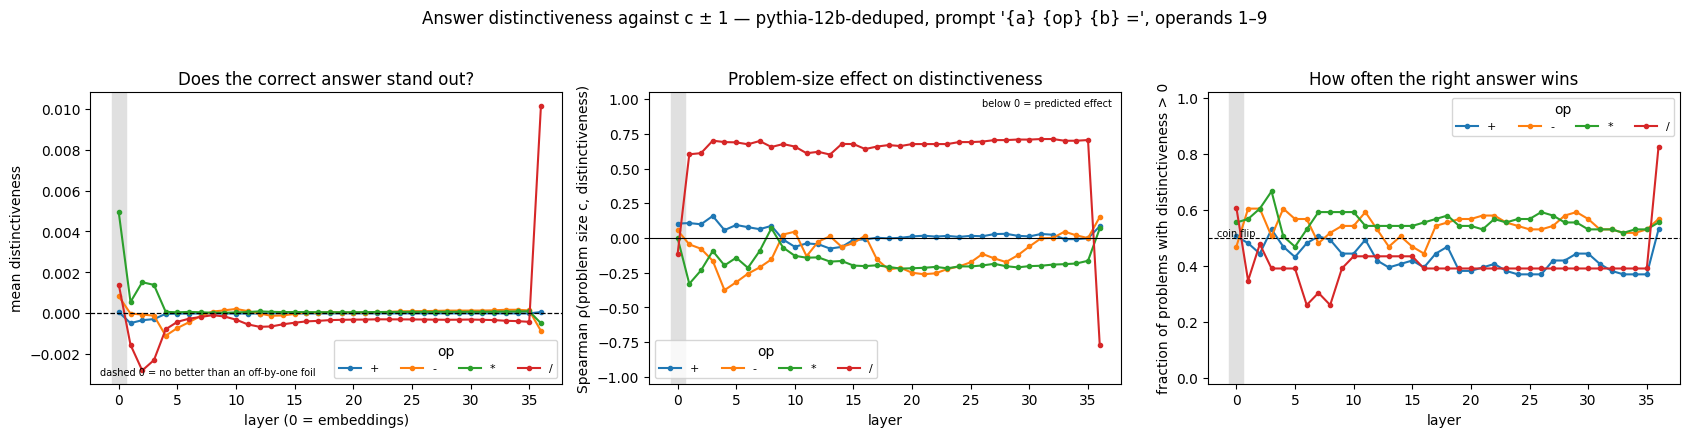

In [22]:
# ── Layer profile ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

ax = axes[0]
for op in OPS:
    s = foil[foil["op"] == op]
    ax.plot(s["layer"], s["mean_distinct"], "o-", ms=3, color=OP_COLORS[op], label=op)
ax.axhline(0, color="k", lw=.9, ls="--")
ax.text(0.02, 0.02, "dashed 0 = no better than an off-by-one foil",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=7)
ax.set_xlabel("layer (0 = embeddings)"); ax.set_ylabel("mean distinctiveness")
ax.set_title("Does the correct answer stand out?")
ax.legend(title="op", fontsize=8, ncol=4)

ax = axes[1]
for op in OPS:
    s = foil[foil["op"] == op]
    ax.plot(s["layer"], s["rho"], "o-", ms=3, color=OP_COLORS[op], label=op)
ax.axhline(0, color="k", lw=.8)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("layer"); ax.set_ylabel("Spearman ρ(problem size c, distinctiveness)")
ax.set_title("Problem-size effect on distinctiveness")
ax.text(0.98, 0.98, "below 0 = predicted effect", transform=ax.transAxes,
        ha="right", va="top", fontsize=7)
ax.legend(title="op", fontsize=8, ncol=4, loc="lower left")

ax = axes[2]
for op in OPS:
    s = foil[foil["op"] == op]
    ax.plot(s["layer"], s["frac_positive"], "o-", ms=3, color=OP_COLORS[op], label=op)
ax.axhline(0.5, color="k", ls="--", lw=.8)
ax.text(0.02, 0.5, "coin flip", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=7)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("layer"); ax.set_ylabel("fraction of problems with distinctiveness > 0")
ax.set_title("How often the right answer wins")
ax.legend(title="op", fontsize=8, ncol=4)

for _ax in axes:
    _ax.axvspan(-0.6, 0.6, color="0.88", zorder=0)

fig.suptitle(f"Answer distinctiveness against c ± 1 — {MODEL_TAG}, prompt "
             f"{A_TEMPLATES[T_EQ]!r}, operands 1–9", y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_arith_foil_distinctiveness_layer_profile.png"),
            dpi=150, bbox_inches="tight")
plt.show()

Headline layer 5 of 36



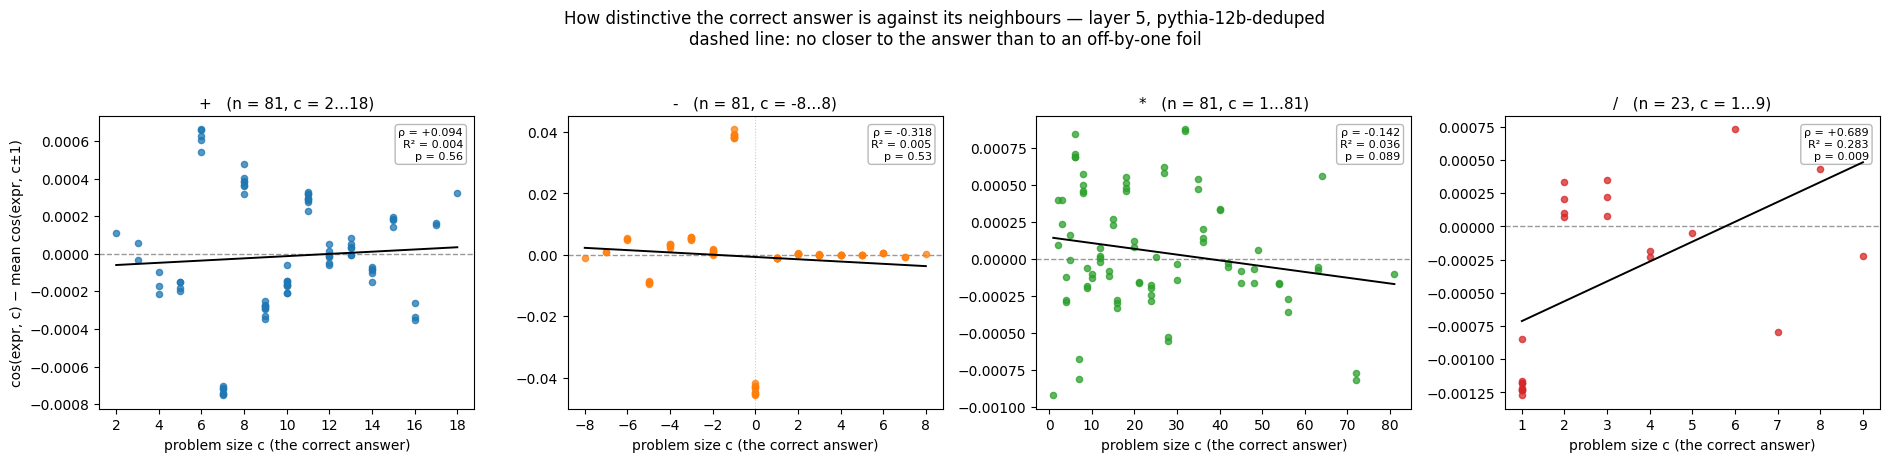

In [23]:
# Layer to plot. Set explicitly rather than picked by whichever layer shows the strongest trend.
FBEST = 5
ftab  = foil_tabs[FBEST]
print(f"Headline layer {FBEST} of {N_LAYERS}\n")

fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
for j, op in enumerate(OPS):
    s  = ftab[ftab["op"] == op]
    ax = axes[j]
    ax.axhline(0, color="0.6", lw=1, ls="--", zorder=1)
    ax.scatter(s["c"], s["distinctive"], s=20, color=OP_COLORS[op], alpha=.75, zorder=3)
    lr = stats.linregress(s["c"].astype(float), s["distinctive"].astype(float))
    xx = np.linspace(s["c"].min(), s["c"].max(), 50)
    ax.plot(xx, lr.intercept + lr.slope * xx, color="k", lw=1.4, zorder=4)
    rho = stats.spearmanr(s["c"], s["distinctive"])[0]
    ax.text(.97, .96, f"ρ = {rho:+.3f}\nR² = {lr.rvalue ** 2:.3f}\np = {lr.pvalue:.2g}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=.9))
    if op == "-":
        ax.axvline(0, color="0.8", lw=.8, ls=":", zorder=1)
    ax.set_title(f"{op}   (n = {len(s)}, c = {s.c.min()}…{s.c.max()})", fontsize=11)
    ax.set_xlabel("problem size c (the correct answer)")
    if j == 0:
        ax.set_ylabel("cos(expr, c) − mean cos(expr, c±1)")

fig.suptitle(f"How distinctive the correct answer is against its neighbours — layer {FBEST}, "
             f"{MODEL_TAG}\ndashed line: no closer to the answer than to an off-by-one foil",
             y=1.04, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "part5nb_arith_foil_distinctiveness_scatter.png"), dpi=150,
            bbox_inches="tight")
plt.show()

In [24]:
foil_summary = {
    "model": MODEL_NAME, "revision": REVISION,
    "measure": "cos(expr, c) - mean(cos(expr, c-1), cos(expr, c+1))",
    "expr_template": A_TEMPLATES[T_EQ], "answer_template": TEMPLATES[ANS_TI],
    "headline_layer": FBEST, "n_layers": N_LAYERS, "by_operation": {},
}
for op in OPS:
    r = foil[(foil["layer"] == FBEST) & (foil["op"] == op)].iloc[0]
    b = _f1.loc[_f1[_f1["op"] == op]["rho"].idxmin()]
    foil_summary["by_operation"][op] = {
        "n": int((PROB["op"] == op).sum()),
        "c_range": [int(PROB.loc[PROB["op"] == op, "c"].min()),
                    int(PROB.loc[PROB["op"] == op, "c"].max())],
        "mean_distinctiveness": float(r["mean_distinct"]),
        "frac_positive": float(r["frac_positive"]),
        "p_mean_vs_zero": float(r["p_vs_0"]),
        "rho": float(r["rho"]), "p": float(r["p"]), "R2": float(r["r2"]),
        "best_layer_by_rho": int(b["layer"]), "best_rho": float(b["rho"]),
    }
with open(os.path.join(TAB_DIR, f"arith_foil_distinctiveness_summary_{MODEL_TAG}.json"), "w") as f:
    json.dump(foil_summary, f, indent=2)
print(json.dumps(foil_summary, indent=2))

_r = {op: foil_summary["by_operation"][op]["rho"] for op in OPS}
_m = {op: foil_summary["by_operation"][op]["mean_distinctiveness"] for op in OPS}
print()
print(f"Sentence-ready: at layer {FBEST} of {MODEL_TAG}, the correct answer's advantage over its "
      f"neighbours c ± 1 averaged " + ", ".join(f"{v:+.5f} ({op})" for op, v in _m.items())
      + ", and related to problem size with "
      + ", ".join(f"ρ({op}) = {v:+.3f}" for op, v in _r.items()) + " (Spearman).")

{
  "model": "EleutherAI/pythia-12b-deduped",
  "revision": "step143000",
  "measure": "cos(expr, c) - mean(cos(expr, c-1), cos(expr, c+1))",
  "expr_template": "{a} {op} {b} =",
  "answer_template": " {}",
  "headline_layer": 5,
  "n_layers": 36,
  "by_operation": {
    "+": {
      "n": 81,
      "c_range": [
        2,
        18
      ],
      "mean_distinctiveness": -1.2788218831745793e-05,
      "frac_positive": 0.43209876543209874,
      "p_mean_vs_zero": 0.7273269287396977,
      "rho": 0.09392953650854775,
      "p": 0.5583553998951231,
      "R2": 0.00435421264769307,
      "best_layer_by_rho": 13,
      "best_rho": -0.07598857595994778
    },
    "-": {
      "n": 81,
      "c_range": [
        -8,
        8
      ],
      "mean_distinctiveness": -0.000715969310255695,
      "frac_positive": 0.5679012345679012,
      "p_mean_vs_zero": 0.7406194287174621,
      "rho": -0.3183387860978227,
      "p": 0.5313076011486382,
      "R2": 0.004979675061860042,
      "best_layer_by_rh